### Das Primäre Ziel dieses Notebooks war die Untersuchung eines möglichen Zusammenhangs zwischen dem wirtschaftlichen Wohlstand eines Landes, gemessen am BIP pro Kopf und der Mortalität durch übertragbare Krankheiten. 

In [160]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm




Es wurde die Datei country_lookup.csv geladen und nicht die finale base_data104_with_lookup.csv, da in der country_lookup-Datei die Todesursachen noch nicht gemappt sind. Dadurch lassen sich die Cause-Codes (ICD-10) mit einem einfacheren Verfahren besser zuordnen.

In [161]:
df = pd.read_csv("Data_Files/country_lookup.csv")
#Da wir nur die Spalten Country, Year, Cause und Deaths1 brauchen, filtern wir den DataFrame entsprechend
df = df[["Country", "Year", "Cause", "Sex", "Deaths1"]]
#Kurzer Check der Dimensionen des DataFrames
print("Reihen:", len(df))
print("Spalten:", df.columns.tolist())


Reihen: 4710902
Spalten: ['Country', 'Year', 'Cause', 'Sex', 'Deaths1']


Hier wollen wir herausfinden, ob Todesursachen ohne Todesfälle mit 0 oder einem anderen Wert angegeben sind und wie viele Einträge tatsächlich keine Todesfälle enthalten

In [162]:
#Konvertiert die Spalte "Deaths1" in numerische Werte, wobei nicht konvertierbare Werte in NaN umgewandelt werden
df["Deaths1"] = pd.to_numeric(df["Deaths1"], errors="coerce")

#Überprüft auf NaN-Werte und Zeros in der Spalte "Deaths1"
num_missing = df["Deaths1"].isna().sum()
num_zeros = (df["Deaths1"] == 0).sum()

print(f"{num_missing} NaN werte in 'Deaths at all ages'")
print(f"{num_zeros} Null werte in 'Deaths at all ages'")


0 NaN werte in 'Deaths at all ages'
7602 Null werte in 'Deaths at all ages'


Im nächsten Schritt führen wir eine Analyse der allgemeinen Datenqualität unseres Datensatzes durch, um unter anderem zu bestimmen, welche Länder ausreichend Daten enthalten und sich für einen Vergleich eignen.

Wieviele Länder sind in unserem Datensatz?

In [163]:
df["Country"].nunique()

124

Welche Länder sind im Datensatz enthalten?

In [164]:
sorted(df["Country"].unique())

['Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Bahamas',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Canada',
 'Cayman Islands',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Fiji',
 'France',
 'French Guiana',
 'Georgia',
 'Germany',
 'Greece',
 'Grenada',
 'Guadeloupe',
 'Guatemala',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hong Kong SAR',
 'Hungary',
 'Iceland',
 'Iran (Islamic Republic of)',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kiribati',
 'Kuwait',
 'Kyrgyzstan',
 'Latvia',
 'Lebanon',
 'Lithuania',
 'Luxembourg',
 'Maldives',
 'Malta',
 'Martinique',
 'Mauritius',
 'Mayotte',
 'Mexico',
 'Micronesia (Federated States of)',
 'Mongolia',
 'Mont

Wieviele Einträge pro Land sind im Datensatz enthalten

In [165]:
df["Country"].value_counts()


Country
Brazil                       307521
United States of America     160718
Mexico                       155631
Japan                        139281
Germany                      135943
                              ...  
Qatar                           710
Montenegro                      624
Kiribati                        469
Solomon Islands                 463
Saint Pierre and Miquelon       209
Name: count, Length: 124, dtype: int64

Wie viele Jahre sind pro Land im Datensatz enthalten? (coverage)

In [166]:
coverage = df.groupby("Country")["Year"].nunique().reset_index(name="Years_Reported").sort_values("Years_Reported", ascending=False)
print(coverage)


                        Country  Years_Reported
27               Czech Republic              30
28                      Denmark              29
109                 Switzerland              28
47                      Hungary              28
65                        Malta              27
..                          ...             ...
14                     Botswana               1
49   Iran (Islamic Republic of)               1
9                       Belarus               1
100                      Serbia               1
89                        Qatar               1

[124 rows x 2 columns]


In diesem Abschnitt wurde der Datensatz bereinigt und hinsichtlich der Datenverfügbarkeit analysiert. Dabei wurden ungültige Länder- und Jahresangaben entfernt sowie unterschiedliche Ländernamen vereinheitlicht, um eine konsistente Zusammenfassung der Daten zu ermöglichen.

Anschliessend wurde gezählt, wie viele Einträge pro Land und Jahr vorhanden sind, und eine Länder-Jahres-Übersicht erstellt, wobei fehlende Werte als keine vorhandenen Daten interpretiert wurden. Für die Jahre 2010 bis 2020 wurden nur Länder mit mindestens 2'000 Einträgen berücksichtigt. Die Ergebnisse wurden abschliessend in einer Heatmap visualisiert.

Überseegebiete wurden nur dann aggregiert, wenn sie integrale administrative Einheiten des jeweiligen Mutterstaates darstellen und in internationalen Gesundheitsstatistiken üblicherweise gemeinsam berichtet werden. Andere Gebiete und kleine Staaten wurden als eigenständige Einheiten beibehalten, um die epidemiologische Vergleichbarkeit zu gewährleisten.

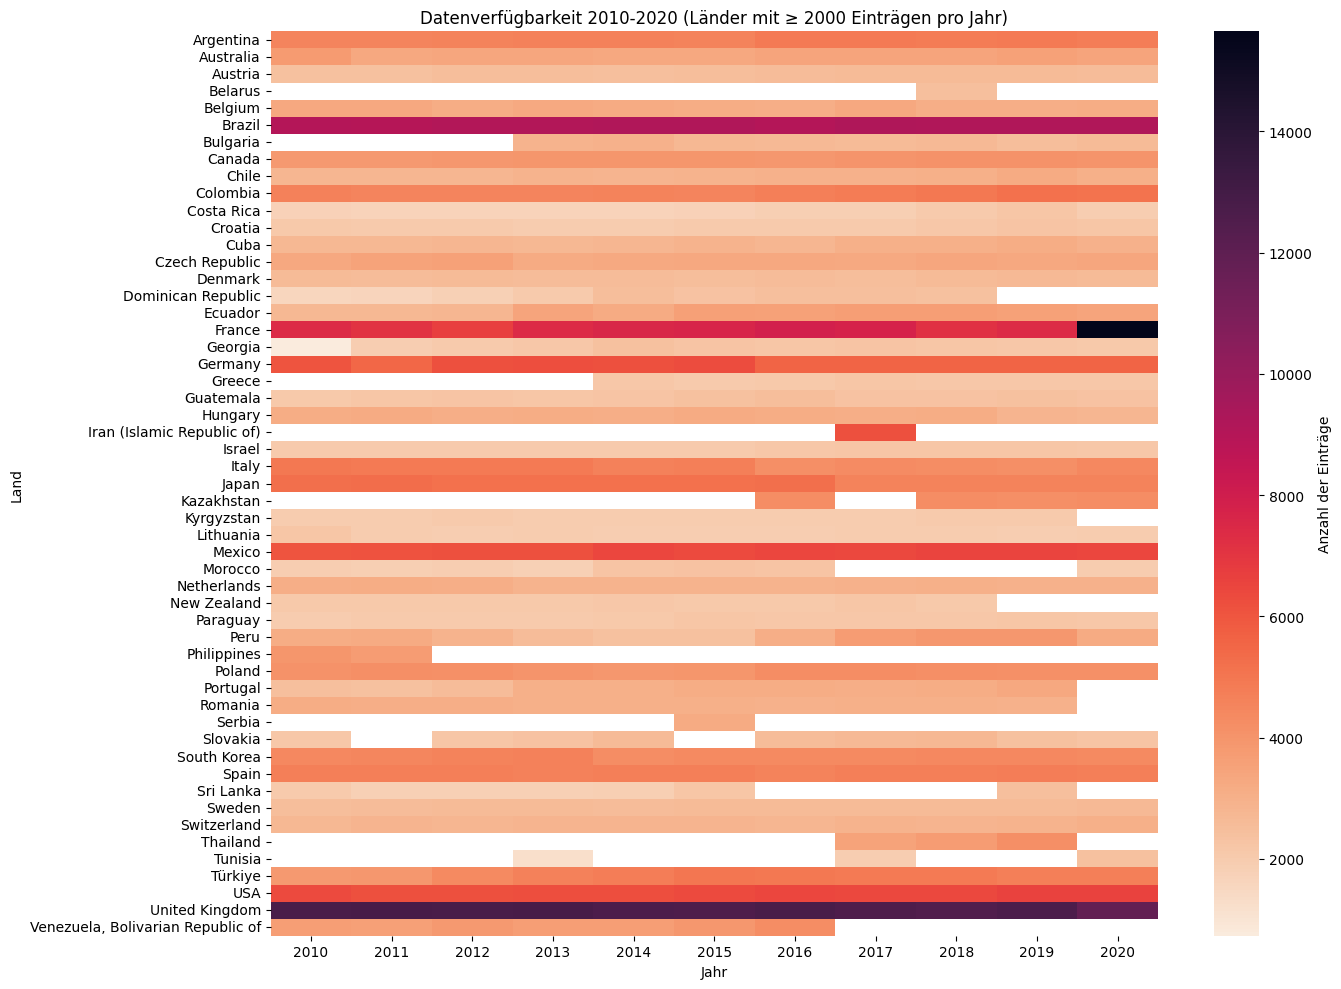

In [167]:
#Stellt sicher, dass die Spalte "Year" numerisch ist und entfernt Zeilen mit ungültigen oder fehlenden Werten in den Spalten "Country" oder "Year"
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Country", "Year"])

#Einheitliche Länderkodierung
country_map = {
    "United States of America": "USA",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States",}
df["Country_clean"] = df["Country"].replace(country_map)

#Zählt die Anzahl der Einträge pro Land und Jahr
count_df = (df.groupby(["Country_clean", "Year"]).size().reset_index(name="Entries"))

#Bereitet die Heatmap-Daten vor
all_countries = sorted(df["Country_clean"].unique())
all_years = sorted(df["Year"].unique())

heatmap_data = (count_df.pivot(index="Country_clean", columns="Year", values="Entries").reindex(index=all_countries, columns=all_years))

#Filtert die Jahre von 2010 bis 2020
years_filter = [y for y in heatmap_data.columns if 2010 <= y <= 2020]
filtered_years_data = heatmap_data[years_filter]

#Es werden nur Länder mit mindestens 2000 Einträgen pro Jahr berücksichtigt
mindestens = 2000
filtered_heatmap_data = filtered_years_data[filtered_years_data.max(axis=1) >= mindestens]

#Plottet die Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(filtered_heatmap_data, cmap="rocket_r", cbar_kws={"label": "Anzahl der Einträge"},linewidths=0.0)
plt.title("Datenverfügbarkeit 2010-2020 (Länder mit ≥ 2000 Einträgen pro Jahr)")
plt.xlabel("Jahr")
plt.ylabel("Land")
plt.tight_layout()
plt.show()


Mithilfe der Heatmap lässt sich grob erkennen, dass die Jahre 2010 bis 2020 eine ähnliche Anzahl an Einträgen aufweisen. Aus diesem Grund wurde im Notebook "Übersicht" zusätzlich ein Säulendiagramm erstellt, um ein Jahr mit der höchsten Datenverfügbarkeit zu identifizieren. Auf dieser Grundlage wurde schliesslich das Jahr 2017 für die weitere Analyse ausgewählt.

Nun schauen wir uns an, wieviele Einträge die Länder für das Jahr 2017 haben.

In [168]:
df_2017 = df[df["Year"] == 2017]
counts = df_2017["Country"].value_counts()
print(counts)


Country
Brazil                        9230
Mexico                        6441
United States of America      6415
Iran (Islamic Republic of)    6205
Germany                       5589
                              ... 
Rodrigues                      109
British Virgin Islands          84
Turks and Caicos Islands        75
Anguilla                        67
Montserrat                      30
Name: count, Length: 93, dtype: int64


Der Datensatz wird weiter bereinigt, indem wir zunächst alle im Datensatz enthaltenen Länder identifizieren. Anschliessend wird der Datensatz auf das zuvor ausgewählte Jahr 2017 gefiltert. Dabei wird überprüft, wie viele Einträge und wie viele unterschiedliche Länder für dieses Jahr im Datensatz vorhanden sind.

In [169]:
#Liste aller Länder im Datensatz
all_countries = sorted(df["Country_clean"].dropna().unique())
print(f"Es wurden {len(all_countries)} Länder im Datensatz gefunden.")

#Filtert den DataFrame für das Jahr 2017
df_2017 = df[df["Year"] == 2017].copy()

print(f"Nach dem Filtrieren sind {len(df_2017):,} Reihen für das Jahr 2017 vorhanden.")
print(f"Es sind {df_2017['Country_clean'].nunique()} Länder im Jahr 2017 vertreten.")




Es wurden 114 Länder im Datensatz gefunden.
Nach dem Filtrieren sind 208,555 Reihen für das Jahr 2017 vorhanden.
Es sind 83 Länder im Jahr 2017 vertreten.


Wir bereiten die Spalte "Cause" auf, indem wir alle Werte als String speichern, Leerzeichen entfernen und die Codes in Grossbuchstaben umwandeln. Anschliessend entfernen wir aggregierte ICD-Codes, also Einträge, die keine spezifischen Diagnosen darstellen (z. B. dreibuchstabige Sammelcodes wie "AAA"). Dadurch bleiben nur detaillierte ICD-10-Codes für die weitere Analyse übrig.

In [170]:
df_2017["Cause"] = df_2017["Cause"].astype(str).str.strip().str.upper()

#Entfernt Einträge mit Ursachen, die nur aus drei Grossbuchstaben bestehen
df_2017_backup = df_2017[(~df_2017["Cause"].str.fullmatch(r"[A-Z]{3}"))].copy()
df_correct_icd = df_2017[(~df_2017["Cause"].str.fullmatch(r"[A-Z]{3}"))].copy()


In diesem Schritt werden die ICD-10-Codes anhand ihres Anfangsbuchstabens in übergeordnete Krankheitskategorien eingeteilt. Dabei werden übertragbare Krankheiten, nicht-übertragbare Krankheiten sowie Verletzungen und externe Ursachen unterschieden. Die zugehörige Kategorie wird anschliessend für jede Todesursache in einer neuen Spalte gespeichert und für die weitere Analyse verwendet.

Quelle: https://icd.who.int/browse10/2019/en

In [171]:
def categorize_icd10(code):
    
    c = str(code)
    first = c[0]

    if first in ["A", "B"]:
        return "Communicable Diseases"

    if first in list("CDEFGHIJKLMN"):
        return "Noncommunicable Diseases"

    if first in list("STVWXY"):
        return "Injuries & External Causes"

    return "Other/Unclassified"

df_correct_icd["Category"] = df_correct_icd["Cause"].apply(categorize_icd10)

In diesem Schritt werden die Todesfälle pro Land, Jahr und Kategorie (z. B. übertragbar / nicht-übertragbar / Verletzungen) aggregiert, indem die Spalte Deaths1 aufsummiert wird. Anschliessend wird für jede Kategorie der prozentuale Anteil an allen Todesfällen eines Landes in einem bestimmten Jahr berechnet und in der Spalte "Percent" gespeichert

In [172]:
df_with_icd = (df_correct_icd.groupby(["Country_clean", "Year", "Category"], as_index=False)["Deaths1"].sum())

df_with_icd["Percent"] = (df_with_icd["Deaths1"] /df_with_icd.groupby(["Country_clean", "Year"])["Deaths1"].transform("sum") * 100)


Der aggregierte Datensatz wird nun für das Jahr 2017 gefiltert und exemplarisch für Schweiz, Kirgisistan und Brasilien ausgegeben. Die Ergebnisse werden nach dem prozentualen Anteil sortiert, um zu sehen, welche Kategorie in jedem Land im Jahr 2017 den grössten Anteil an Todesfällen ausmacht

In [173]:
swiss_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Switzerland") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(swiss_2017)

kirgistan_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Kyrgyzstan") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(kirgistan_2017)

brazil_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Brazil") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(brazil_2017)

    Country_clean  Year                    Category  Deaths1    Percent
292   Switzerland  2017    Noncommunicable Diseases    59166  88.345702
291   Switzerland  2017  Injuries & External Causes     3734   5.575548
293   Switzerland  2017          Other/Unclassified     3263   4.872258
290   Switzerland  2017       Communicable Diseases      808   1.206492
    Country_clean  Year                    Category  Deaths1    Percent
174    Kyrgyzstan  2017    Noncommunicable Diseases    26460  79.780498
175    Kyrgyzstan  2017          Other/Unclassified     3046   9.184104
173    Kyrgyzstan  2017  Injuries & External Causes     2856   8.611228
172    Kyrgyzstan  2017       Communicable Diseases      804   2.424169
   Country_clean  Year                    Category  Deaths1    Percent
38        Brazil  2017    Noncommunicable Diseases   992855  75.636644
37        Brazil  2017  Injuries & External Causes   158777  12.095784
39        Brazil  2017          Other/Unclassified   106158   8.087

Um zwischen Ländern mit höherem und mittlerem Einkommen zu unterscheiden, werden wir die Einkommensklassifikation der Weltbank verwenden. Dort werden die Schweiz, Japan,  Kanada, als High-Income (Bruttonationaleinkommen pro Kopf >$13'935) Länder eingestuft, während Mexico, Brasilien und Kolumbien zu den Upper-Middle-Income (Bruttonationaleinkommen pro Kopf zwischen $4'496 - $13'935) Länder zählen. Kirgistan und Nicaragua gelten als Lower-Middle-Income (Bruttonationaleinkommen pro Kopf zwischen $1'136 - $4'495) Länder. 

Quelle: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519

In diesem Abschnitt werden die ausgewählten Länder für das Jahr 2017 miteinander verglichen. Dazu werden die prozentualen Anteile der Todesursachenkategorien berechnet, in einer Tabelle zusammengefasst und dann in einem gestapelten Balkendiagramm visualisiert.


 Prozentualer Anteil der Tode nach Ursache für das Jahr 2017 

    Country  Communicable Diseases  Injuries & External Causes  Noncommunicable Diseases  Other/Unclassified
Switzerland                   1.21                        5.58                     88.35                4.87
      Japan                   1.85                        5.12                     83.58                9.46
     Canada                   1.54                        6.85                     89.36                2.24
     Mexico                   2.28                       11.43                     81.56                4.73
   Colombia                   2.70                       12.59                     80.20                4.51
     Brazil                   4.18                       12.10                     75.64                8.09
  Nicaragua                   2.74                        9.03                     79.04                9.19
 Kyrgyzstan                   2.42                        8.61  

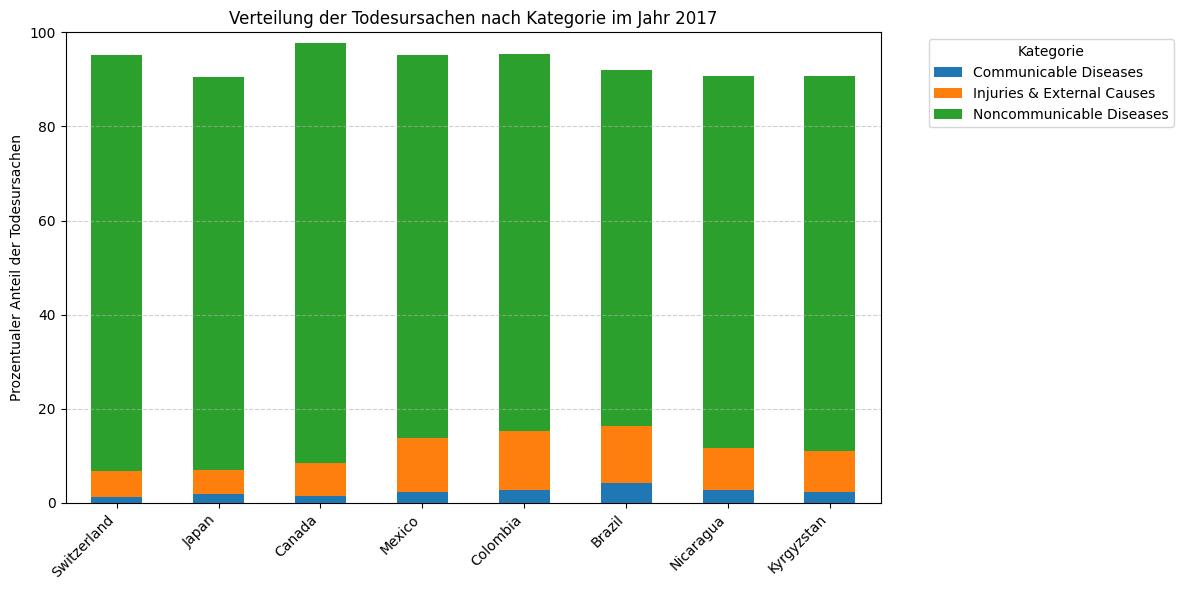

In [174]:

countries_to_compare = ["Switzerland", "Japan", "Canada", "Mexico", "Colombia", "Brazil", "Nicaragua", "Kyrgyzstan"]
#Filtert auf 2017 und Länder der Vergleichsgruppe

df_2017_comp = df_with_icd[(df_with_icd["Year"] == 2017) & (df_with_icd["Country_clean"].isin(countries_to_compare))].copy()

#Pivot-Tabelle erstellen
table_clean = (df_2017_comp.pivot(index="Country_clean", columns="Category", values="Percent").round(2).reset_index().rename(columns={"Country_clean": "Country"}))

#Erstellt eine sortierte Liste der Länder für die Anzeige
country_order = ["Switzerland", "Japan", "Canada", "Mexico", "Colombia", "Brazil", "Nicaragua", "Kyrgyzstan"]
table_clean["Country"] = pd.Categorical(table_clean["Country"], categories=country_order, ordered=True)
table_clean = table_clean.sort_values("Country")

print("\n Prozentualer Anteil der Tode nach Ursache für das Jahr 2017 \n")
print(table_clean.to_string(index=False))

#Definiert die Reihenfolge der Kategorien für die Anzeige
category_order = ["Communicable Diseases","Injuries & External Causes", "Noncommunicable Diseases"]

#Erstellt das gestapelte Balkendiagramm
ax = table_clean.set_index("Country")[category_order].plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Verteilung der Todesursachen nach Kategorie im Jahr 2017")
plt.ylabel("Prozentualer Anteil der Todesursachen")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategorie", bbox_to_anchor=(1.05, 1))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Die Abbildung stellt die Anteile der Todesursachenkategorien pro Land im Jahr 2017 getrennt nach Kategorien dar.

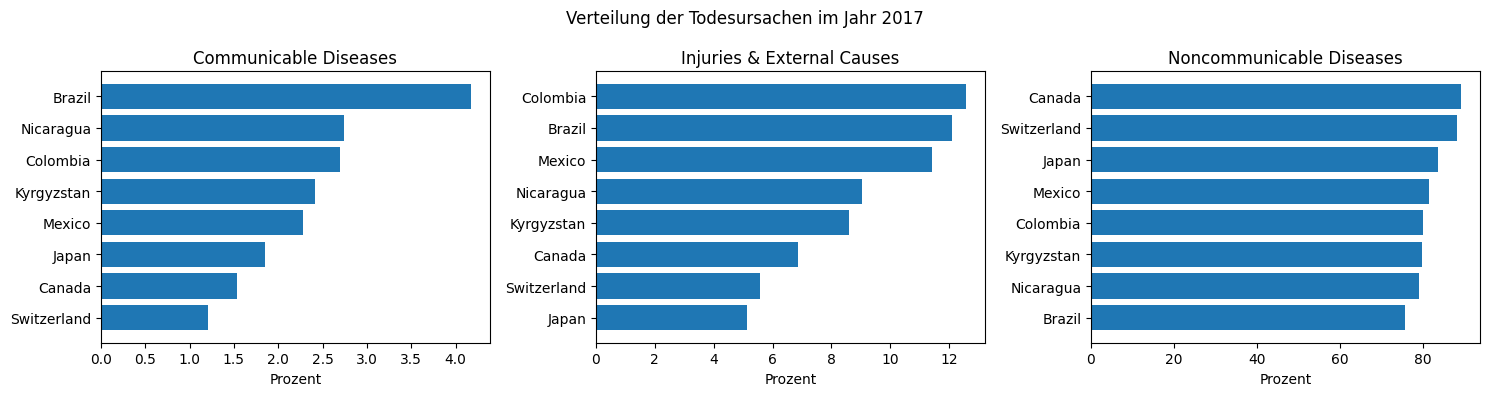

In [175]:
categories = ["Communicable Diseases", "Injuries & External Causes","Noncommunicable Diseases"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cat in zip(axes, categories):
    plot_data = table_clean.sort_values(cat)
    ax.barh(plot_data["Country"], plot_data[cat])
    ax.set_title(cat)
    ax.set_xlabel("Prozent")

plt.suptitle("Verteilung der Todesursachen im Jahr 2017")
plt.tight_layout()
plt.show()


Die Abbildungen verdeutlichen, dass nicht-übertragbare Krankheiten in allen untersuchten Ländern den mit Abstand grössten Anteil an den Todesursachen ausmachen. In Ländern mit höherem Einkommen wie der Schweiz, Japan und Kanada ist der Anteil übertragbarer Krankheiten sehr gering, während Verletzungen und externe Ursachen ebenfalls nur einen kleinen Teil ausmachen. In Ländern mit mittlerem und niedrigerem Einkommen, insbesondere in Nicaragua, Kirgisistan, Brasilien und Kolumbien, ist hingegen ein höherer Anteil sowohl übertragbarer Krankheiten als auch von Verletzungen zu beobachten.

Auffällig ist jedoch, dass selbst in Ländern mit niedrigerem bzw. unterem mittlerem Einkommensniveau wie Kirgisistan und Nicaragua der Anteil übertragbarer Krankheiten vergleichsweise gering ausfällt. Dies widerspricht teilweise der Erwartung, dass in diesen Ländern übertragbare Krankheiten einen deutlich höheren Anteil an den Todesursachen haben sollten. Stattdessen dominieren auch hier nicht-übertragbare Krankheiten, was darauf hindeutet, dass sich die Krankheitslast in diesen Ländern bereits stärker in Richtung chronischer Erkrankungen verschoben hat. Darauf gehen wir allerdings am Ende dieses Notebooks nochmal genauer ein.

### Other / Unclassified

In diesem Abschnitt wird die Kategorie "Other / Unclassified" näher untersucht, um besser zu verstehen, welche Todesursachen in diese Restkategorie fallen. Dazu werden alle ICD-10-Codes analysiert, die im vorherigen Schritt keiner der drei Hauptkategorien zugeordnet werden konnten.

Zur genaueren Einordnung wurden diese Todesursachen anhand ihrer ICD-10-Präfixe weiter unterteilt. Dadurch lässt sich beurteilen, ob die Kategorie "Other / Unclassified" überwiegend durch schlecht definierte Ursachen, maternale und perinatale Erkrankungen, angeborene Fehlbildungen oder spezielle ICD-Codes geprägt ist. Die Analyse erfolgt auf Länderebene für das Jahr 2017 und liefert Hinweise auf mögliche Unterschiede in der Datenqualität sowie in den Praktiken der Todesursachenkodierung zwischen den Ländern.

In [176]:
def refine_other(code):
    c = str(code).strip().upper()
    if c.startswith("O"):
        return "Maternal causes"
    if c.startswith("P"):
        return "Perinatal conditions"
    if c.startswith("Q"):
        return "Congenital disorders"
    if c.startswith("R"):
        return "Ill-defined and unknown causes"


In diesem Schritt werden die Todesfälle der Kategorie "Other / Unclassified" für das Jahr 2017 auf Länderebene nach weiterführenden Unterkategorien aggregiert. Für jedes Land wird die Anzahl der Todesfälle pro Unterkategorie aufsummiert und anschliessend der prozentuale Anteil jeder Unterkategorie an allen "Other"-Todesfällen des jeweiligen Landes berechnet. Die Ergebnisse werden nach Ländern und absteigendem prozentualen Anteil sortiert, um die interne Zusammensetzung dieser Restkategorie vergleichbar darzustellen.

In [177]:
df_2017_other = df_2017_backup.copy()
df_2017_other["Other_Subcategory"] = df_2017_other["Cause"].apply(refine_other)

other_summary = (
    df_2017_other
    .dropna(subset=["Other_Subcategory"])   # keep only O/P/Q/R
    .groupby(["Country_clean", "Other_Subcategory"], as_index=False)["Deaths1"]
    .sum()
)

other_summary["Percent"] = (
    other_summary["Deaths1"] /
    other_summary.groupby("Country_clean")["Deaths1"].transform("sum") * 100
).round(2)

other_summary = other_summary.sort_values(["Country_clean", "Percent"], ascending=[True, False])
print(other_summary.to_string(index=False))


               Country_clean              Other_Subcategory  Deaths1  Percent
                    Anguilla           Perinatal conditions        3    75.00
                    Anguilla                Maternal causes        1    25.00
         Antigua and Barbuda Ill-defined and unknown causes        9    52.94
         Antigua and Barbuda           Perinatal conditions        5    29.41
         Antigua and Barbuda           Congenital disorders        3    17.65
                   Argentina Ill-defined and unknown causes    20544    77.40
                   Argentina           Perinatal conditions     3388    12.76
                   Argentina           Congenital disorders     2365     8.91
                   Argentina                Maternal causes      246     0.93
                     Armenia Ill-defined and unknown causes      194    34.34
                     Armenia           Perinatal conditions      189    33.45
                     Armenia           Congenital disorders     

Die Tabelle zeigt die prozentuale Zusammensetzung der "Other / Unclassified"-Todesfälle im Jahr 2017 nach Unterkategorien (O/P/Q/R) für jedes verfügbare Land. 

Der Code bereitet die Daten in einer breiten Tabellenform auf und visualisiert für jedes Land die prozentuale Zusammensetzung der Kategorie "Other/Unclassified" als gestapeltes horizontales Balkendiagramm.


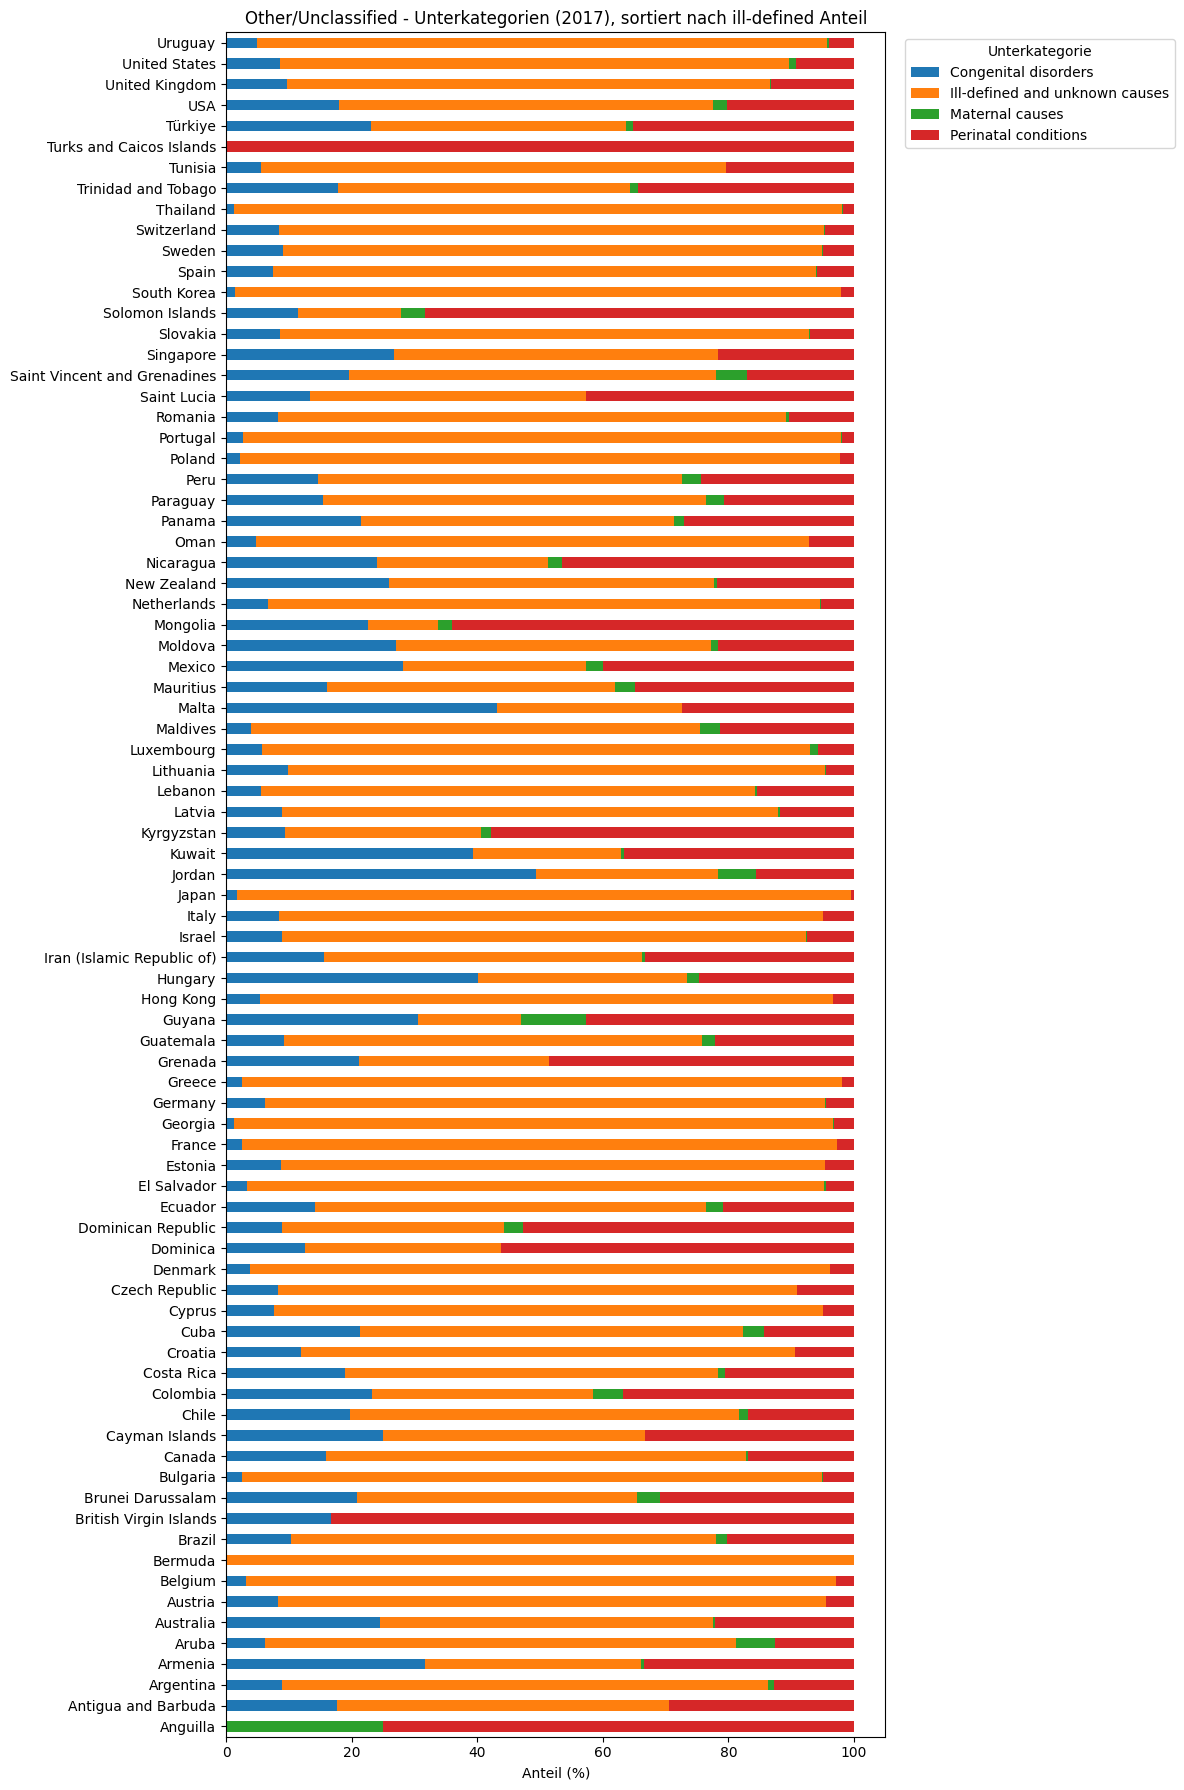

In [178]:
#Erstellt die Heatmap-Daten
heat = (other_summary.pivot(index="Country_clean", columns="Other_Subcategory", values="Percent").fillna(0))
wide = heat.copy()
ax = wide.plot(kind="barh", stacked=True, figsize=(12, 18))
plt.title("Other/Unclassified - Unterkategorien (2017), sortiert nach ill-defined Anteil")
plt.xlabel("Anteil (%)")
plt.ylabel("")
plt.legend(title="Unterkategorie", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



Die Abbildung zeigt die prozentuale Zusammensetzung der Kategorie "Other / Unclassified" im Jahr 2017, unterteilt nach ICD-10-Unterkategorien und sortiert nach dem Anteil schlecht definierter und unbekannter Ursachen. In den meisten Ländern wird diese Restkategorie deutlich von ill-defined and unknown causes dominiert, was auf Unterschiede in der Qualität und Detailtiefe der Todesursachenkodierung hinweist.

Einzelne Länder weisen zudem erhöhte Anteile perinataler oder kongenitaler Ursachen innerhalb der "Other"-Kategorie auf, was darauf hindeutet, dass klinisch relevante Todesursachen nicht immer eindeutig den Hauptkategorien zugeordnet werden konnten. Maternal causes spielen hingegen in nahezu allen Ländern nur eine untergeordnete Rolle. 

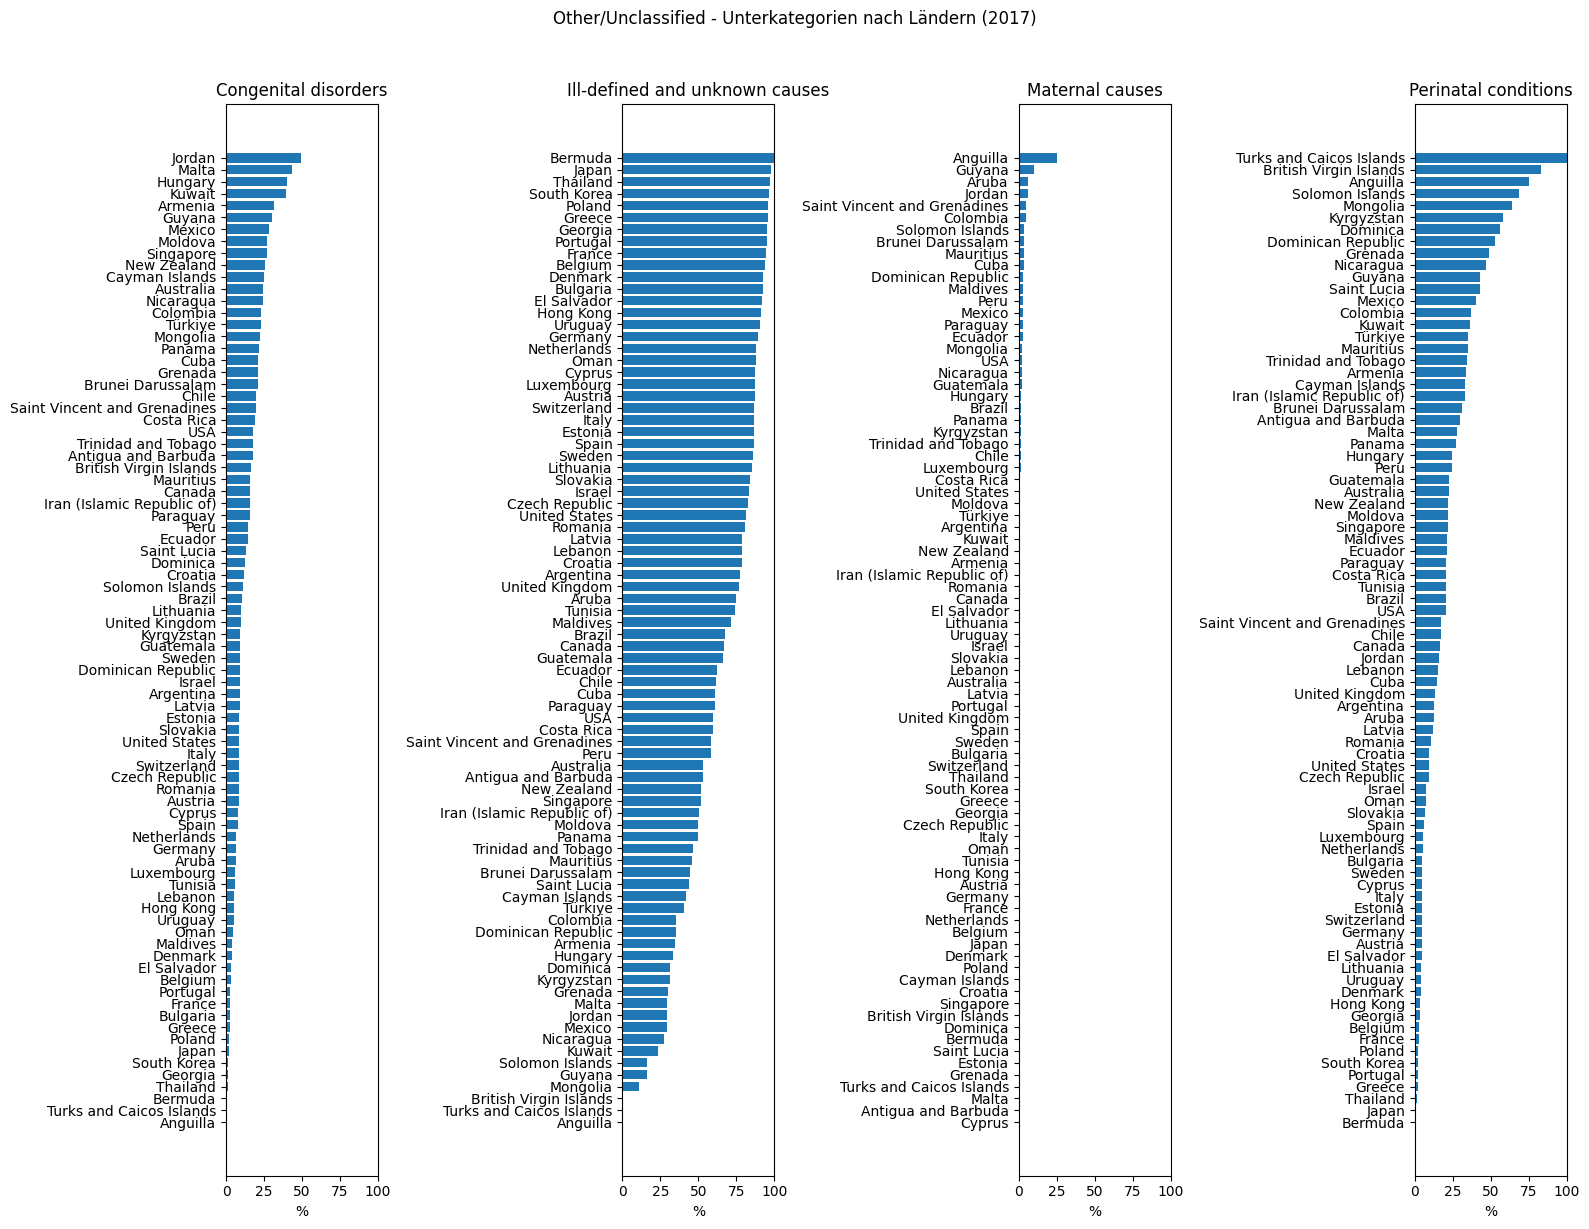

In [179]:
categories = heat.columns.tolist()
fig, axes = plt.subplots(1, len(categories), figsize=(4*len(categories), 12))

# falls nur 1 Kategorie -> axes ist kein Array
axes = np.atleast_1d(axes)

for ax, cat in zip(axes, categories):
    tmp = heat[[cat]].sort_values(cat, ascending=True)
    ax.barh(tmp.index, tmp[cat].values)
    ax.set_title(cat)
    ax.set_xlabel("%")
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlim(0, 100)

plt.suptitle("Other/Unclassified - Unterkategorien nach Ländern (2017)", y=1.02)
plt.tight_layout()
plt.show()


Zur besseren Lesbarkeit wird die Zusammensetzung von "Other / Unclassified" zusätzlich als Small-Multiples-Darstellung gezeigt. Für jede Unterkategorie wird separat visualisiert, in welchen Ländern ihr Anteil innerhalb der "Other"-Todesursachen besonders hoch ist. Dadurch lassen sich länderspezifische Ausreisser und Muster pro Unterkategorie klarer erkennen als in einer einzigen gestapelten Gesamtgrafik.
Die Grafik zeigt, dass "Ill-defined and unknown causes" in vielen Ländern den mit Abstand grössten Anteil innerhalb von "Other / Unclassified" ausmachen – ein Hinweis auf Unterschiede in Diagnosequalität, Meldepraktiken oder Datenverfügbarkeit. Perinatal conditions und maternal causes fallen vor allem in einzelnen (häufig kleineren oder weniger entwickelten) Ländern stark ins Gewicht, was auf strukturelle Unterschiede in der Gesundheitsversorgung hindeutet. Congenital disorders sind insgesamt gleichmässiger verteilt, weisen aber ebenfalls einzelne Ausreisser auf. Insgesamt macht die Small-Multiples-Darstellung deutlich, dass sich die Zusammensetzung von Other stark länder- und ursachenspezifisch unterscheidet und nicht von einem einzelnen Treiber dominiert wird.

### Häufigste Todesursachen pro Land



Quelle: https://data.worldbank.org/indicator/SP.POP.TOTL?end=2024&start=2003

Zur Berechnung vergleichbarer Todesraten werden Bevölkerungsdaten der World Bank für das Jahr 2017 verwendet. Der Datensatz wird bereinigt, auf gültige Länder beschränkt und auf die Variablen Country Name, ISO3 und Bevölkerung 2017 reduziert. Die Bevölkerungswerte werden in ein numerisches Format überführt, um spätere Berechnungen zu ermöglichen.

In [180]:
pop_raw = pd.read_csv("Data_Files/API_SP.POP.TOTL_DS2_en_csv_v2_34.csv", skiprows=4)
pop_raw.columns = pop_raw.columns.str.strip()
pop_raw = pop_raw[pop_raw["Country Code"].notna()]
pop_2017 = pop_raw[["Country Name", "Country Code", "2017"]].rename(columns={"Country Name": "Country_wb", "Country Code": "ISO3", "2017": "Population"})
pop_2017["Population"] = pd.to_numeric(pop_2017["Population"], errors="coerce")


Da sich die Ländernamen im Todesursachen-Datensatz und in den World-Bank-Daten teilweise unterscheiden, wird ein Mapping definiert, das alternative Schreibweisen und politische Namensvarianten vereinheitlicht. Auf dieser Basis wird eine World-Bank-kompatible Ländernamensspalte erzeugt. Einzelne Territorien ohne konsistente Zuordnung werden ausgeschlossen, um fehlerhafte Verknüpfungen beim späteren Merge zu vermeiden.

In [181]:
wb_map = {
    "USA": "United States",
    "United States of America": "United States",

    "South Korea": "Korea, Rep.",
    "Republic of Korea": "Korea, Rep.",

    "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Iran": "Iran, Islamic Rep.",

    "Türkiye": "Turkiye",
    "Turkey": "Turkiye",

    "Kyrgyzstan": "Kyrgyz Republic",
    "Slovakia": "Slovak Republic",
    "Czech Republic": "Czechia",

    "Hong Kong": "Hong Kong SAR, China",
    "Hong Kong SAR": "Hong Kong SAR, China",

    "Saint Lucia": "St. Lucia",
    "Saint Vincent and Grenadines": "St. Vincent and the Grenadines",

    "Virgin Islands (US)": "Virgin Islands (U.S.)",
    "Puerto Rico": "Puerto Rico (US)",
}

df_2017_backup["Country_wb"] = df_2017_backup["Country_clean"].replace(wb_map)
df_wb_naming = df_2017_backup[~df_2017_backup["Country_clean"].isin(["Anguilla", "Montserrat"])].copy()



Die Bevölkerungsdaten für 2017 werden anhand des harmonisierten Ländernamens (Country_wb) per Left Join an den Todesursachen-Datensatz angefügt.

In [182]:
df_wb_naming = df_wb_naming.merge(pop_2017[["Country_wb", "Population"]],on="Country_wb",how="left")


Zur Qualitätskontrolle werden anschliessend alle Länder identifiziert, für die nach dem Merge keine Bevölkerungsdaten vorliegen, um verbleibende Zuordnungsprobleme transparent zu machen.

In [183]:
missing_after = sorted(df_wb_naming.loc[df_wb_naming["Population"].isna(), "Country_wb"].dropna().unique())
missing_after[:50], len(missing_after)


([], 0)

In [184]:
deaths_countries = set(df_wb_naming["Country_wb"].dropna().unique())
wb_countries = set(pop_2017["Country_wb"].dropna().unique())

sorted(deaths_countries - wb_countries)[:50]


[]

Es gibt keine Länder im Deaths-Datensatz, die nicht auch im World-Bank-Datensatz vorkommen (Differenzmenge leer) - und entsprechend sind keine fehlenden Bevölkerungswerte mehr übrig (0 Missing)

In [185]:
# 1) Are there any duplicate country keys in pop_2017? (should be 0)
pop_2017["Country_wb"].duplicated().sum()

# 2) Does each country in df_wb_naming have exactly one population value?
print(df_wb_naming.groupby("Country_wb")["Population"].nunique().max())



1


Zusätzlich zeigen die Checks, dass pop_2017 keine doppelten Länder-Keys enthält und dass jedem Land in df_wb_naming eindeutig genau ein Bevölkerungswert zugeordnet ist. Der Merge ist damit konsistent und ohne Mehrdeutigkeiten.

Hier werden die Todesursachen zunächst auf einen groben Ursachenblock reduziert (erste drei Zeichen der Cause-Codierung), anschliessend pro Land und Ursachenblock die Todesfälle aufsummiert und mit der jeweiligen Bevölkerung verknüpft, um daraus eine vergleichbare Kennzahl Todesfälle pro 100’000 Einwohner zu berechnen.

In [186]:
df_wb_naming["Cause_block"] = df_wb_naming["Cause"].astype(str).str[:3]

analysis_df = (df_wb_naming.groupby(["Country_wb", "Cause_block"], as_index=False).agg(Deaths=("Deaths1", "sum"),Population=("Population", "first")))

analysis_df["deaths_per_100k"] = analysis_df["Deaths"] / analysis_df["Population"] * 100000


Aus der ICD-Code-Tabelle für die causes wird eine eindeutige Zuordnung von Ursachenblock zu Ursachenname erstellt, an den Analyse-Datensatz gemergt und anschliessend pro Land die zehn Ursachenblöcke mit der höchsten Todesrate pro 100'000 Einwohner ausgewählt.

In [187]:
# 1) Read cause code lookup (ICD block -> name)
codes = pd.read_csv("codes_Files/causes_codes.csv", sep=";", header=None, dtype=str)

cause_lookup = (codes[[6, 8]].rename(columns={6: "Cause_block", 8: "Cause_name"}).dropna().drop_duplicates(subset=["Cause_block"]))

# 2) Ensure analysis_df has no old Cause_name before merging (prevents _x/_y)
analysis_df = analysis_df.drop(columns=["Cause_name"], errors="ignore")

# 3) Merge names onto analysis_df
analysis_df = analysis_df.merge(cause_lookup, on="Cause_block", how="left")

# 4) Top N causes per country
top_causes_per_country = (analysis_df.sort_values(["Country_wb", "deaths_per_100k"], ascending=[True, False]).groupby("Country_wb").head(10))


Mit diesem Code werden für ausgewählte Länder (Schweiz, Japan, Nicaragua) die Top-10-Todesursachen nach Todesrate pro 100’000 als Small-Multiples (nebeneinander) visualisiert und dabei eine einheitliche x-Achsen-Skalierung erzwungen, damit die Länderwerte direkt vergleichbar sind.

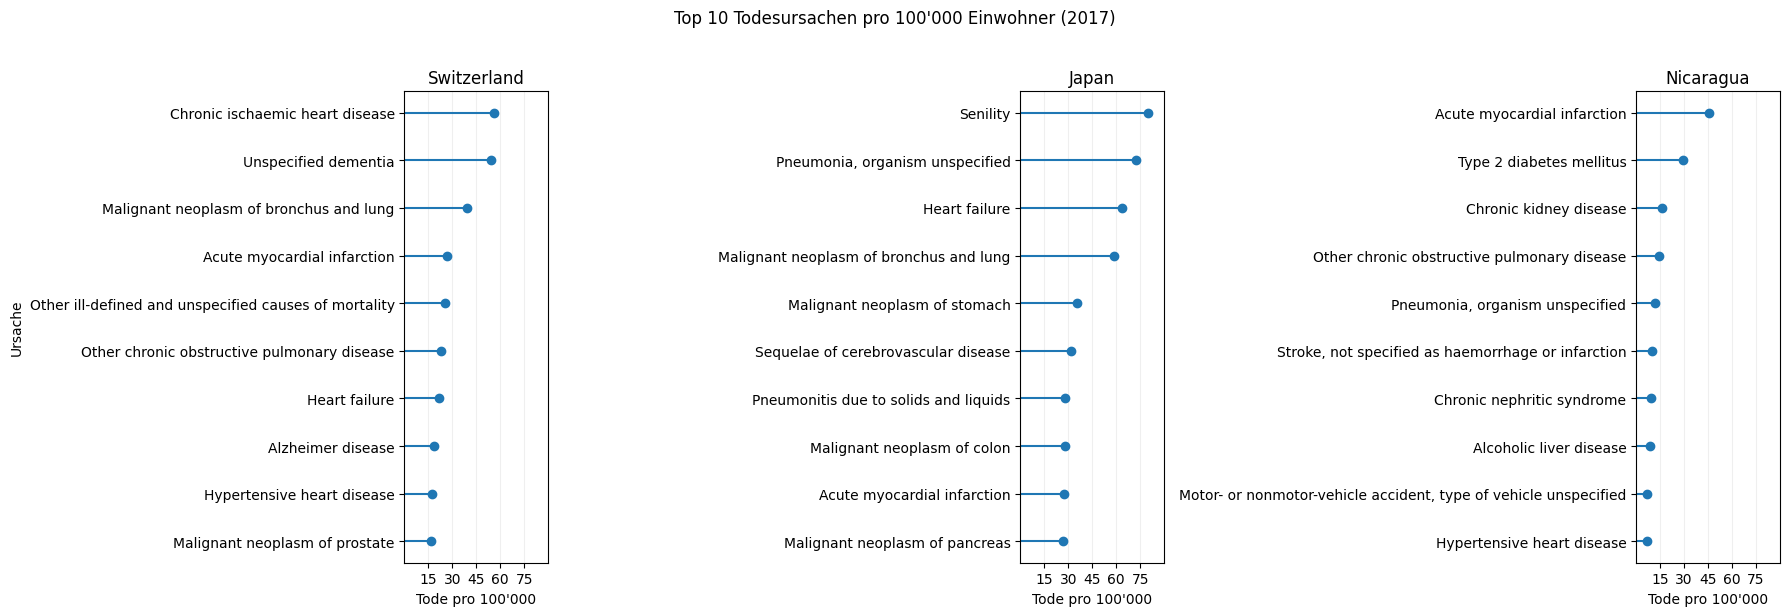

In [188]:
countries = ["Switzerland", "Japan", "Nicaragua"]
fig, axes = plt.subplots(1, len(countries), figsize=(18, 6), sharex=True)

# pick a common max (e.g., 50) OR compute one from data (see below)
xmax = 90
xticks = [15, 30, 45, 60, 75]

for ax, country in zip(axes, countries):
    d = (analysis_df.query("Country_wb == @country").sort_values("deaths_per_100k", ascending=False).head(10).sort_values("deaths_per_100k"))
    ax.hlines(d["Cause_name"], 0, d["deaths_per_100k"])
    ax.plot(d["deaths_per_100k"], d["Cause_name"], marker="o", linestyle="None")
    ax.set_title(country)
    ax.set_xlabel("Tode pro 100'000")
    ax.grid(True, axis="x", alpha=0.2)

    # force same scale
    ax.set_xlim(0, xmax)
    ax.set_xticks(xticks)

axes[0].set_ylabel("Ursache")
plt.suptitle(f"Top 10 Todesursachen pro 100'000 Einwohner (2017)", y=1.02)
plt.tight_layout()
plt.show()


Die Darstellung macht deutliche länder­spezifische Muster sichtbar: In der Schweiz dominieren chronisch-degenerative Erkrankungen wie ischämische Herzkrankheiten, Demenz und Krebs, was typisch für Länder mit hoher Lebenserwartung ist. Japan weist besonders hohe Raten bei altersassoziierten Ursachen (z. B. Senilität, Pneumonie) sowie mehreren Krebsarten auf, was die stark alternde Bevölkerung widerspiegelt. In Nicaragua stehen dagegen kardiovaskuläre Erkrankungen, Diabetes und Nierenerkrankungen im Vordergrund, ergänzt durch vermeidbare Ursachen wie Verkehrsunfälle, was auf unterschiedliche Gesundheitsrisiken und Versorgungsstrukturen hinweist.
Auffällig ist zudem, dass Nicaragua insgesamt deutlich niedrigere Todesraten pro 100’000 Einwohner aufweist als die Schweiz und Japan. Dies ist sehr wahrscheinlich nicht Ausdruck eines geringeren Krankheitsrisikos, sondern hängt wesentlich mit der deutlich jüngeren Altersstruktur der Bevölkerung zusammen. Da viele der dominierenden Todesursachen (kardiovaskuläre Erkrankungen, Krebs, Demenz) stark altersabhängig sind, führt ein niedrigeres Medianalter zu insgesamt geringeren beobachteten Sterberaten, selbst bei vergleichbarer oder schlechterer Gesundheitsversorgung.

Hier werden die Daten über alle Länder aggregiert, indem Todesfälle und Bevölkerungen pro Ursachenblock aufsummiert und daraus globale, nicht altersadjustierte Todesraten pro 100'000 Einwohner berechnet werden; anschliessend werden die 15 häufigsten Todesursachen identifiziert und grafisch dargestellt.

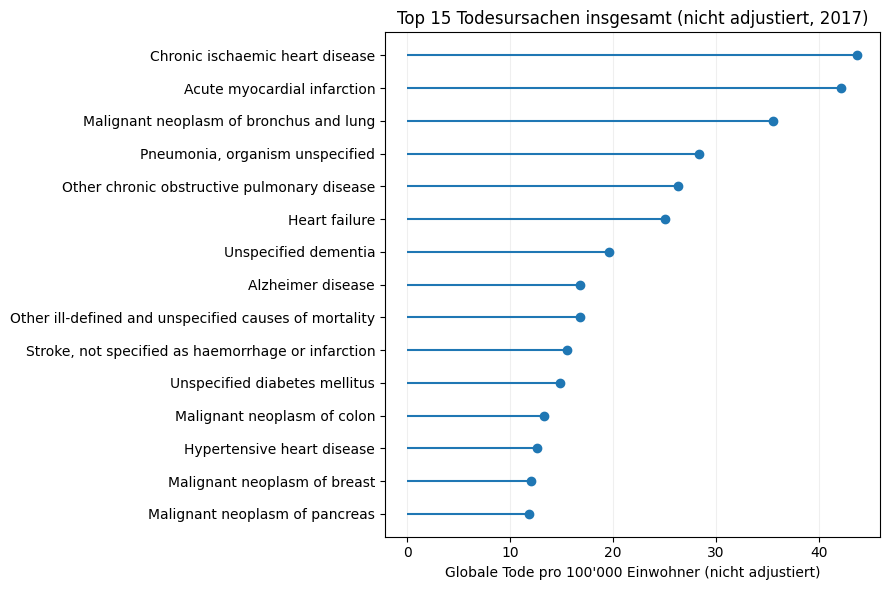

In [189]:
global_cause = (analysis_df.groupby(["Cause_block", "Cause_name"], as_index=False).agg(Deaths=("Deaths", "sum"), Population=("Population", "sum")))

global_cause["global_deaths_per_100k"] = global_cause["Deaths"] / global_cause["Population"] * 100000

global_top = global_cause.sort_values("global_deaths_per_100k", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.hlines(global_top["Cause_name"][::-1], 0, global_top["global_deaths_per_100k"][::-1])
plt.plot(global_top["global_deaths_per_100k"][::-1], global_top["Cause_name"][::-1], "o")
plt.xlabel("Globale Tode pro 100'000 Einwohner (nicht adjustiert)")
plt.title(f"Top {15} Todesursachen insgesamt (nicht adjustiert, 2017)")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


Die Grafik zeigt die global häufigsten Todesursachen im Jahr 2017, gemessen als Todesfälle pro 100’000 Einwohner auf Basis aggregierter Länderwerte. Dominant sind vor allem kardiovaskuläre Erkrankungen (chronische ischämische Herzkrankheit, akuter Myokardinfarkt, Herzinsuffizienz), gefolgt von Krebserkrankungen sowie Atemwegserkrankungen und Demenz.

Die dargestellten Raten sind nicht altersadjustiert und daher primär als deskriptive Gesamtübersicht zu verstehen. Eine Altersstandardisierung wurde bewusst nicht vorgenommen, da die Altersgruppenstruktur der WHO-Todesursachendaten nicht mit den verfügbaren Altersgruppen der World-Bank-Bevölkerungsdaten übereinstimmt. Entsprechend reflektieren die Ergebnisse sowohl die tatsächliche Krankheitslast als auch die jeweilige Altersstruktur der Bevölkerung und sind daher insbesondere zwischen Ländern mit stark unterschiedlichem Medianalter nur eingeschränkt vergleichbar.

Nun wird für jedes Land die führende Todesursache anhand der höchsten Todesrate pro 100'000 Einwohner bestimmt und anschliessend ausgezählt, wie häufig jede Ursache als Rang 1 über alle Länder hinweg vorkommt. Zur übersichtlichen Darstellung werden die acht häufigsten Top-1-Ursachen beibehalten und alle übrigen in "Other" zusammengefasst. Ein Kreisdiagramm visualisiert die Verteilung, während eine Tabelle die Anzahl der Länder sowie den prozentualen Anteil je führender Ursache ausweist.

Insgesamt gibt es 18 verschiedene führende Todesursachen unter den 80 Ländern für das Jahr 2017.


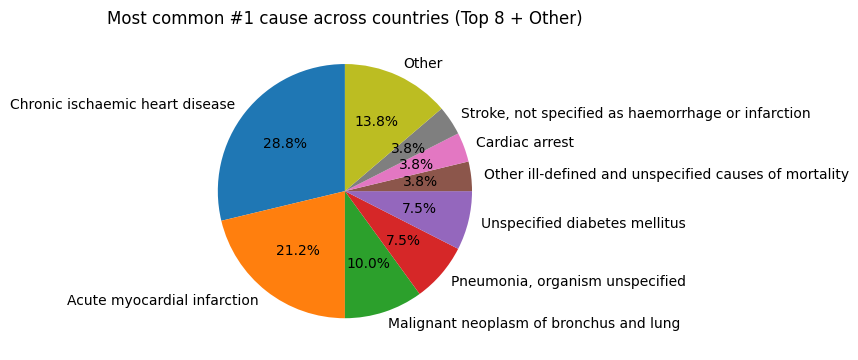

,num_countries,share_percent
Cause_name,,
Chronic ischaemic heart disease,23,28.75
Acute myocardial infarction,17,21.25
Malignant neoplasm of bronchus and lung,8,10.00
"Pneumonia, organism unspecified",6,7.50
Unspecified diabetes mellitus,6,7.50
Other ill-defined and unspecified causes of mortality,3,3.75
Cardiac arrest,3,3.75
"Stroke, not specified as haemorrhage or infarction",3,3.75
Heart failure,2,2.50


In [190]:
#Top 1 Ursache
top1 = (analysis_df.sort_values(["Country_wb", "deaths_per_100k"], ascending=[True, False]).groupby("Country_wb").head(1))
#Zählt, wie oft jede Ursache als Top 1 Ursache vorkommt
top1_counts = (top1.groupby("Cause_name").size().sort_values(ascending=False))
#Behält nur die Top 8 und fasst den Rest unter "Other" zusammen
topN = top1_counts.head(8)
other = top1_counts.iloc[8:].sum()
pie_series = topN.copy()
if other > 0:
    pie_series.loc["Other"] = other
pie_series.to_frame("num_countries")
n_countries = top1["Country_wb"].nunique()
n_unique_top1 = top1["Cause_name"].nunique()

# Number of unique leading causes
n_unique_causes = top1_counts.shape[0]
print(f"Insgesamt gibt es {n_unique_causes} verschiedene führende Todesursachen unter den {n_countries} Ländern für das Jahr 2017.")


plt.figure(figsize=(8, 8))
plt.pie(pie_series.values, labels=pie_series.index, autopct=lambda p: f"{p:.1f}%", startangle=90)
plt.title(f"Most common #1 cause across countries (Top 8 + Other)")
plt.tight_layout()
plt.show()




summary_table = (
    top1_counts
    .rename("num_countries")
    .to_frame()
)

summary_table["share_percent"] = summary_table["num_countries"] / n_countries * 100

summary_table

Die Analyse zeigt, welche Todesursache im Jahr 2017 in wie vielen Ländern die häufigste Ursache war. Am häufigsten tritt die chronisch-ischämische Herzkrankheit auf, die in 23 Ländern (28,75 %) die führende Todesursache darstellt. Es folgt der akute Myokardinfarkt mit 17 Ländern (21,25 %) sowie das bösartige Neoplasma der Bronchien und der Lunge mit 8 Ländern (10,0 %).

Zusammen machen diese drei Ursachen rund 60 % der Länder aus, in denen sie jeweils als häufigste Todesursache auftreten. Dies zeigt, dass nur wenige Ursachen in vielen Ländern den ersten Rang einnehmen, während zahlreiche andere Ursachen lediglich in einzelnen Ländern dominieren. Gleichzeitig zeigt sich eine gewisse Heterogenität: Insgesamt treten 18 verschiedene Ursachen zumindest in einem Land als häufigste Todesursache auf. Diese selteneren Ursachen sind im Kreisdiagramm entweder als sehr kleine Segmente oder im Sammelsegment "Other" zusammengefasst.

Die Grafik verdeutlicht somit, dass die globale Mortalität zwar von wenigen Hauptursachen dominiert wird, jedoch deutliche länderspezifische Unterschiede bestehen.

### Geschlechtsspezifische Muster der Todesursachen (global, 2017)

In diesem Abschnitt wird untersucht, wie sich die Verteilung der Todesursachen zwischen Männern und Frauen unterscheidet.  Dafür werden die Todesfälle nach Geschlecht getrennt aggregiert und als prozentuale Anteile innerhalb jedes Geschlechts dargestellt (statt als absolute Zahlen). So werden Unterschiede in der Zusammensetzung sichtbar, ohne dass sie durch unterschiedliche Bevölkerungsgrössen oder Gesamtsterblichkeit je Geschlecht überlagert werden. 
Einträge mit der Geschlechtskodierung 9 (unbekannt) wurden entfernt, da sie keiner eindeutigen Geschlechtskategorie zugeordnet werden können und die Vergleichbarkeit der Ergebnisse beeinträchtigen würden.

Im Code werden zunächst nur valide Geschlechtskategorien (WHO-Codierung 1/2) beibehalten und in sprechende Labels (Male, Female) übersetzt. Anschliessend werden die Ursachen wieder auf den ICD-Ursachenblock (erste drei Zeichen) reduziert und mit den Klartext-Bezeichnungen aus der Lookup-Tabelle verknüpft. Danach werden die Todesfälle nach Country, Sex und Cause aggregiert, bevor über alle Länder pro Geschlecht aufsummiert wird. Aus diesen Summen wird schliesslich der Anteil jeder Ursache an allen Todesfällen innerhalb des jeweiligen Geschlechts berechnet.

In [191]:
sex_map = {1: "Male", 2: "Female"}

df_sex = df_wb_naming[df_wb_naming["Sex"].isin([1, 2])].copy()
df_sex["Sex"] = df_sex["Sex"].map(sex_map)

df_sex["Cause_block"] = df_sex["Cause"].astype(str).str[:3]

df_sex = df_sex.drop(columns=["Cause_name"], errors="ignore")
df_sex = df_sex.merge(cause_lookup, on="Cause_block", how="left")
df_sex["Cause_name"] = df_sex["Cause_name"].fillna(df_sex["Cause_block"])

analysis_sex_df = (
    df_sex
    .groupby(["Country_wb", "Sex", "Cause_block", "Cause_name"], as_index=False)
    .agg(Deaths=("Deaths1", "sum"), Population=("Population", "first"))
)

global_sex = (
    analysis_sex_df
    .groupby(["Sex", "Cause_block", "Cause_name"], as_index=False)
    .agg(Deaths=("Deaths", "sum"))
)

global_sex["share_percent"] = global_sex.groupby("Sex")["Deaths"].transform(lambda s: s / s.sum() * 100)


Die Top-25-Todesursachen werden getrennt nach Männern und Frauen als prozentuale Anteile visualisiert, um Unterschiede in der Ursachenstruktur direkt zu vergleichen.

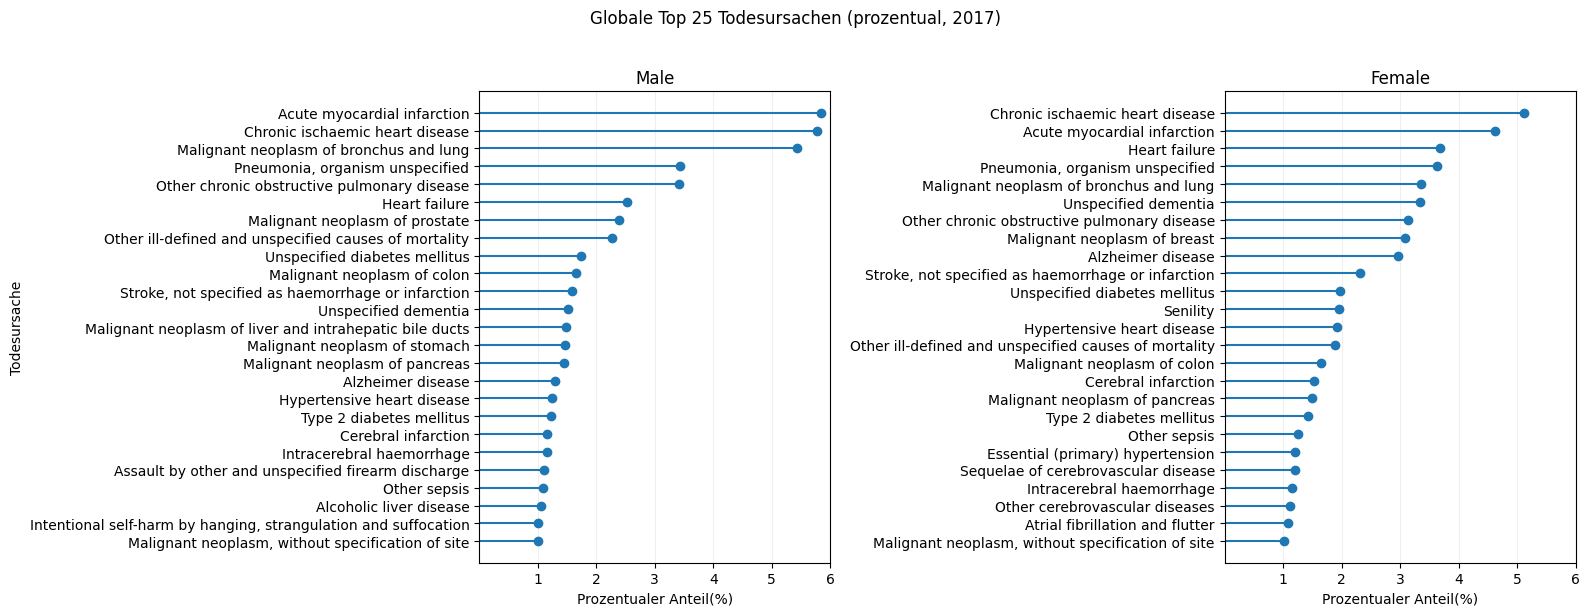

In [192]:
sexes = ["Male", "Female"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for ax, sx in zip(axes, sexes):
    d = (global_sex.query("Sex == @sx").sort_values("share_percent", ascending=False).head(25).sort_values("share_percent"))

    ax.hlines(d["Cause_name"], 0, d["share_percent"])
    ax.plot(d["share_percent"], d["Cause_name"], "o")
    ax.set_title(sx)
    ax.set_xlabel("Prozentualer Anteil(%)")
    ax.grid(True, axis="x", alpha=0.2)

# force same scale on both
for ax in axes:
    ax.set_xlim(0, 6)
    ax.set_xticks([1, 2, 3, 4, 5, 6])

axes[0].set_ylabel("Todesursache")
plt.suptitle("Globale Top 25 Todesursachen (prozentual, 2017)", y=1.02)
plt.tight_layout()
plt.show()


Die Grafik verdeutlicht klare geschlechtsspezifische Unterschiede in der Struktur der Todesursachen. Bei Männern dominieren kardiovaskuläre Erkrankungen und Lungenkrebs, ergänzt durch externe und verhaltensassoziierte Ursachen wie Alkohol­erkrankungen, Gewalt und Suizid, die bei Frauen kaum unter den führenden Ursachen erscheinen.

Bei Frauen zeigen sich dagegen höhere Anteile für altersassoziierte und chronische Erkrankungen wie chronische ischämische Herzkrankheit, Demenz, Alzheimer sowie Brustkrebs, was sowohl biologische Unterschiede als auch die im Durchschnitt höhere Lebenserwartung widerspiegelt. Insgesamt macht die Gegenüberstellung deutlich, dass sich globale Mortalitätsmuster nicht nur in der Höhe, sondern vor allem in der Zusammensetzung der Ursachen zwischen den Geschlechtern systematisch unterscheiden.

Danach wollten wir herausfinden, ob sich die jeweils führende Todesursache pro Land zwischen Männern und Frauen systematisch unterscheidet. Dazu werden zunächst geschlechtsspezifische Todesraten pro 100’000 Einwohner berechnet, wobei die jeweilige Landesbevölkerung als Bezugsgrösse dient. Dann wird für jedes Land und jedes Geschlecht separat die Todesursache mit der höchsten Rate (Top 1) bestimmt.
Im nächsten Schritt wird ausgezählt, wie häufig jede Ursache über alle Länder hinweg als führende Todesursache für Männer bzw. Frauen auftritt. Um die Ergebnisse übersichtlich darzustellen, wurden jeweils nur die häufigsten Ursachen berücksichtigt, während seltener auftretende Ursachen in einer Sammelkategorie "Other" zusammengefasst wurden.

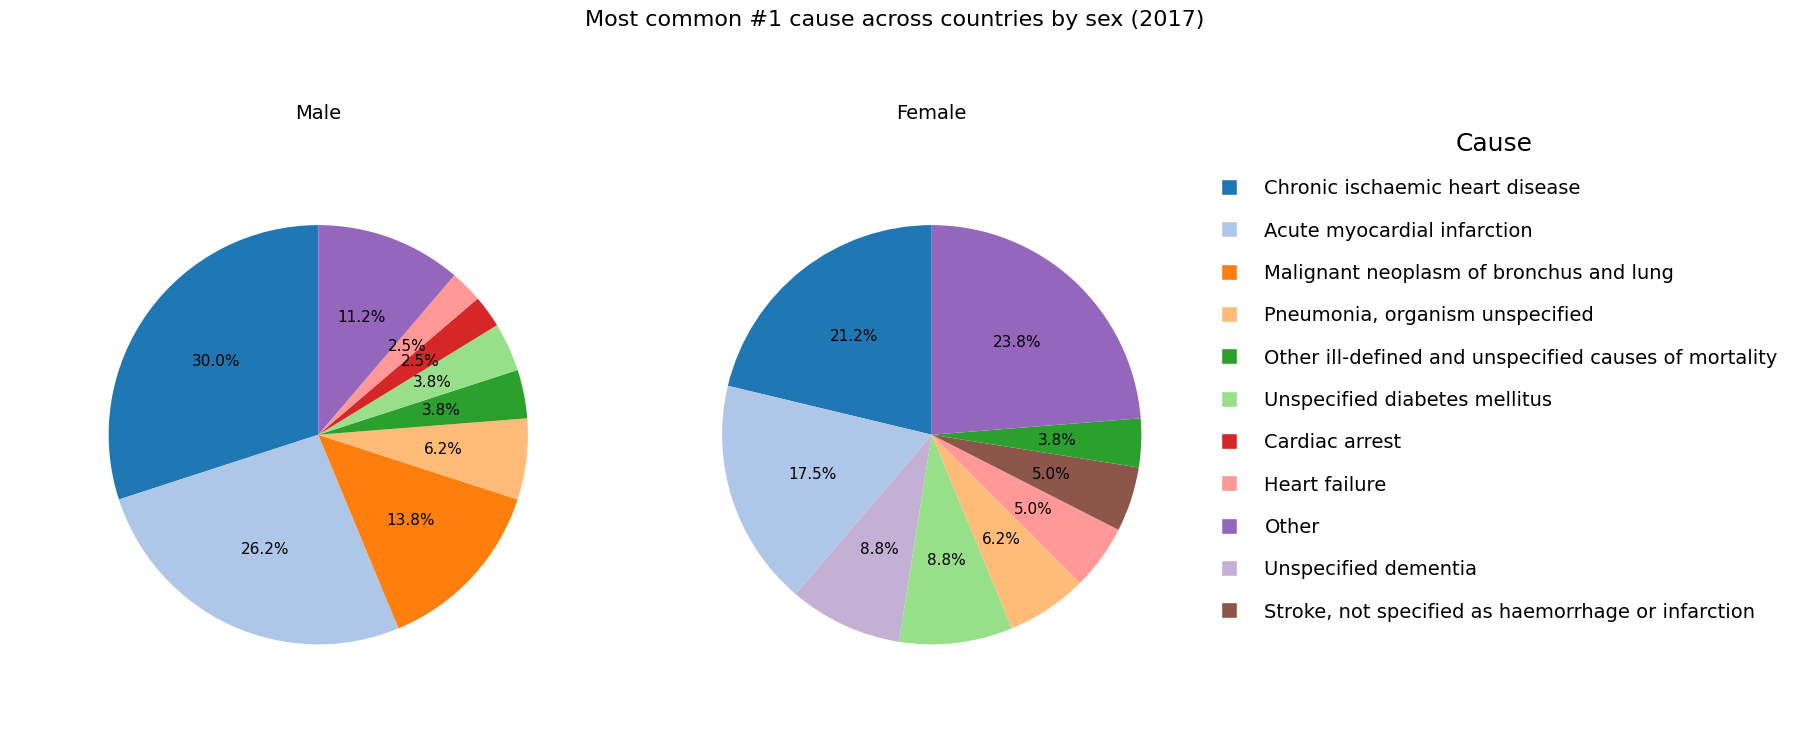

In [193]:
analysis_sex_df["deaths_per_100k_totalpop"] = analysis_sex_df["Deaths"] / analysis_sex_df["Population"] * 100000
top1_sex = (analysis_sex_df.sort_values(["Country_wb", "Sex", "deaths_per_100k_totalpop"], ascending=[True, True, False]).groupby(["Country_wb", "Sex"]).head(1))

def make_pie_series(top1_sex, sex_label, top_n=8):
    counts = (top1_sex[top1_sex["Sex"] == sex_label].groupby("Cause_name").size().sort_values(ascending=False))
    topN = counts.head(top_n)
    other = counts.iloc[top_n:].sum()
    pie = topN.copy()
    if other > 0:
        pie.loc["Other"] = other
    return pie
pie_m = make_pie_series(top1_sex, "Male", 8)
pie_f = make_pie_series(top1_sex, "Female", 8)

# shared legend categories = union
labels = list(dict.fromkeys(list(pie_m.index) + list(pie_f.index)))

# color map fixed by label
base_colors = plt.cm.tab20.colors
color_map = {lab: base_colors[i % len(base_colors)] for i, lab in enumerate(labels)}

def autopct_nonzero(p):
    return f"{p:.1f}%" if p >= 1 else ""

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Male pie in male-sorted order
m_labels = pie_m.index.tolist()
m_colors = [color_map[l] for l in m_labels]
axes[0].pie(pie_m.values, labels=None, autopct=autopct_nonzero, startangle=90, colors=m_colors, radius=0.85, textprops={"fontsize": 11})
axes[0].set_title("Male", fontsize=14)

# Female pie in female-sorted order
f_labels = pie_f.index.tolist()
f_colors = [color_map[l] for l in f_labels]
axes[1].pie(pie_f.values, labels=None, autopct=autopct_nonzero, startangle=90, colors=f_colors, radius=0.85, textprops={"fontsize": 11})
axes[1].set_title("Female", fontsize=14)

# shared legend
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_map[l], markersize=12) for l in labels]
fig.legend(handles, labels, loc="center right", title="Cause", title_fontsize=18, fontsize=14, frameon=False, labelspacing=1.2)
plt.suptitle("Most common #1 cause across countries by sex (2017)", fontsize=16, y=0.97)
plt.tight_layout(rect=[0, 0, 0.7, 0.95])
plt.show()


Bei Männern konzentriert sich der größte Anteil auf chronische ischämische Herzkrankheit und akuten Myokardinfarkt, die zusammen den überwiegenden Teil der Länder abdecken, während nur wenige weitere Ursachen nennenswerte Anteile erreichen.
Bei Frauen verteilt sich die führende Todesursache breiter über mehrere Kategorien, wobei neben kardiovaskulären Erkrankungen auch Demenz, Diabetes, Pneumonie und Schlaganfall in einer grösseren Zahl von Ländern den ersten Rang einnehmen. Der vergleichsweise hohe "Other"-Anteil bei Frauen unterstreicht zudem eine stärkere Heterogenität der führenden Ursachen auf Länderebene.

### Uncertainty of sex differences in causes of death (bootstrap analysis)


Letzlich wird die Analyse über eine rein deskriptive Gegenüberstellung hinaus erweitert, indem geschlechtsspezifische Unterschiede in der Ursachenstruktur statistisch eingeordnet werden. Ziel ist es, nicht nur zu zeigen ob sich Männer und Frauen unterscheiden, sondern wie stabil und robust diese Unterschiede über Länder hinweg sind.

In diesem Abschnitt werden geschlechtsspezifische Unterschiede in der Verteilung der Todesursachen als Sex Gap (Male - Female) analysiert. Dazu werden Todesfälle auf Länderebene nach Geschlecht und Ursache aggregiert und innerhalb jedes Landes in Anteile an allen Todesfällen umgerechnet, um vergleichbare Ursachenprofile zu erhalten.

Der Sex Gap ergibt sich als Differenz der durchschnittlichen Ursachenanteile über alle Länder hinweg und wird mithilfe eines Country-level Bootstraps um 95%-Konfidenzintervalle ergänzt. Durch das Resampling ganzer Länder wird die länderspezifische Heterogenität explizit berücksichtigt, sodass sichtbar wird, welche geschlechtsspezifischen Unterschiede robust bestehen und welche statistisch nicht eindeutig von null zu unterscheiden sind.

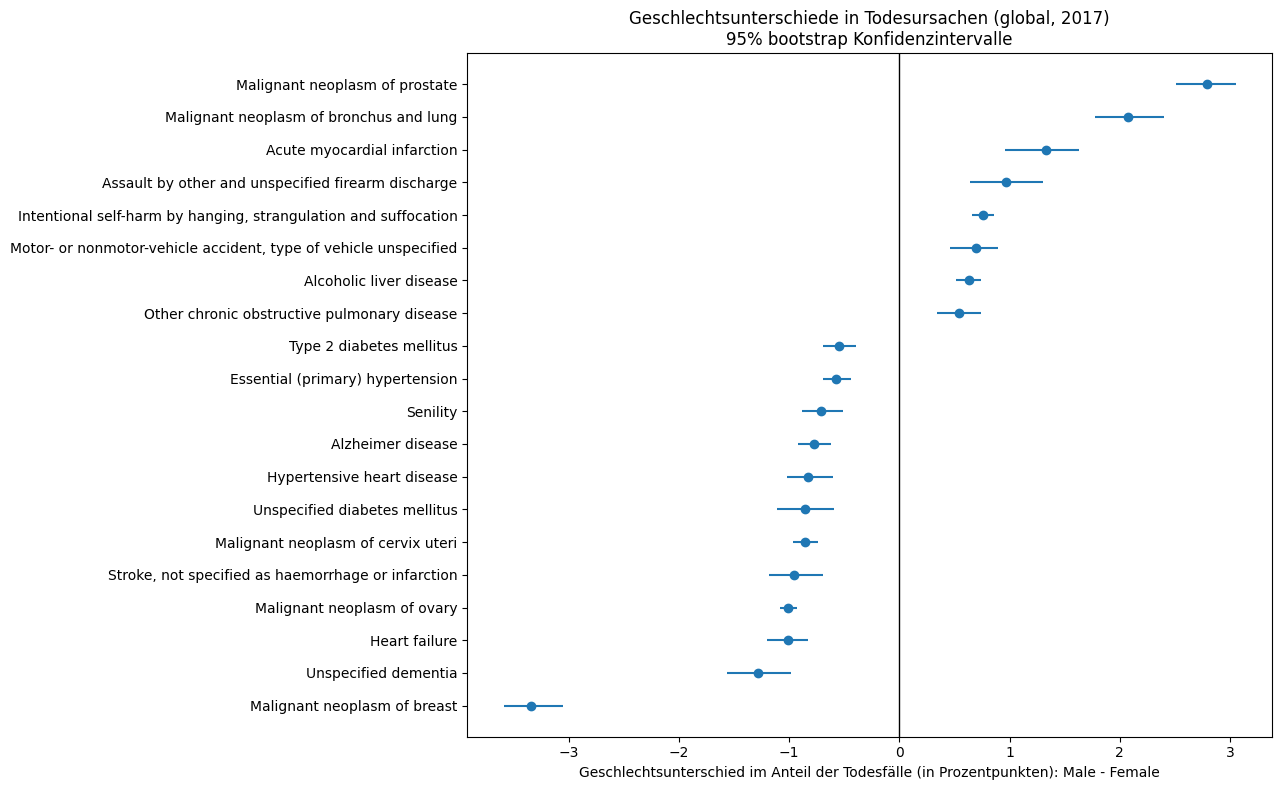

In [194]:
# --- 1) Country-level deaths by sex and cause ---
country_sex_cause = (analysis_sex_df.groupby(["Country_wb", "Sex", "Cause_name"], as_index=False).agg(Deaths=("Deaths", "sum")))

# total deaths per country & sex (for shares)
country_sex_totals = (country_sex_cause.groupby(["Country_wb", "Sex"])["Deaths"].sum().reset_index(name="Total_deaths"))

country_sex_cause = country_sex_cause.merge(country_sex_totals,on=["Country_wb", "Sex"],how="left")

# within-country, within-sex share of deaths by cause
country_sex_cause["share"] = country_sex_cause["Deaths"] / country_sex_cause["Total_deaths"]

# --- 2) Bootstrap sex gap (resample countries) ---
countries = country_sex_cause["Country_wb"].dropna().unique()

boot_results = []

for i in range(1000):
    sampled_countries = np.random.choice(countries, size=len(countries), replace=True)
    sample = country_sex_cause[country_sex_cause["Country_wb"].isin(sampled_countries)]
    agg = (sample.groupby(["Sex", "Cause_name"])["share"].mean().unstack("Sex").fillna(0))
    boot_results.append(agg["Male"] - agg["Female"])

boot_df = pd.DataFrame(boot_results)

# --- 3) Point estimate from original (mean across countries) ---
point_estimate = (country_sex_cause.groupby(["Sex", "Cause_name"])["share"].mean().unstack("Sex").fillna(0))

point_estimate["sex_gap_pp"] = (point_estimate["Male"] - point_estimate["Female"]) * 100

# --- 4) 95% confidence intervals (percent points) ---
conf = pd.DataFrame({"lower": boot_df.quantile(0.025) * 100, "upper": boot_df.quantile(0.975) * 100, "sex_gap_pp": point_estimate["sex_gap_pp"]}).dropna()

# choose top causes by absolute gap
conf_plot = (conf.reindex(conf["sex_gap_pp"].abs().sort_values(ascending=False).head(20).index).sort_values("sex_gap_pp"))

# --- 5) Plot ---
plt.figure(figsize=(10, 8))
plt.errorbar(conf_plot["sex_gap_pp"], conf_plot.index, xerr=[conf_plot["sex_gap_pp"] - conf_plot["lower"], conf_plot["upper"] - conf_plot["sex_gap_pp"]], fmt="o")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Geschlechtsunterschied im Anteil der Todesfälle (in Prozentpunkten): Male - Female")
plt.title("Geschlechtsunterschiede in Todesursachen (global, 2017)\n95% bootstrap Konfidenzintervalle")
plt.tight_layout()
plt.subplots_adjust(left=0.18)
plt.show()

Die Abbildung zeigt geschlechtsspezifische Unterschiede in der Zusammensetzung der Todesursachen als Sex Gap, definiert als Differenz der Ursachenanteile Male - Female in Prozentpunkten. Positive Werte kennzeichnen Ursachen mit höherem Anteil an männlichen Todesfällen, negative Werte solche mit höherem Anteil bei Frauen. Die 95 %-Bootstrap-Konfidenzintervalle quantifizieren die Unsicherheit dieser Unterschiede über Länder hinweg.

Ein ausgeprägter männlicher Überschuss zeigt sich insbesondere bei Prostata- und Lungenkrebs, akutem Myokardinfarkt sowie externen Ursachen wie Gewalt, Suizid und Verkehrsunfällen. Weiblich dominierte Ursachen finden sich vor allem bei Brustkrebs, Demenz und weiteren altersassoziierten Erkrankungen. Konfidenzintervalle, die vollständig auf einer Seite der Null-Linie liegen, weisen auf robuste geschlechtsspezifische Unterschiede hin.

Insgesamt verdeutlicht die Grafik, dass sich die globale Mortalität von Männern und Frauen weniger in der Höhe als in der Struktur der Todesursachen unterscheidet, wobei der Sex Gap diese Unterschiede systematisch sichtbar macht.

### Globaler Zusammenhang zwischen Geschlecht und Todesursachen (χ²-Test und Effektstärke)

Zur Prüfung, ob sich die Gesamtverteilung der Todesursachen zwischen Männern und Frauen systematisch unterscheidet, wird eine Kontingenztafel aus den global aufsummierten Todesfällen pro Ursache und Geschlecht erstellt. Auf dieser Grundlage wird ein Chi-Quadrat-test (χ²) durchgeführt, der bewertet, ob Todesursache und Geschlecht statistisch unabhängig sind. Ergänzend wird mit Cramérs V eine Effektstärke berechnet, um die praktische Relevanz des Zusammenhangs unabhängig von der Stichprobengrösse einzuordnen.

In [195]:
contingency = (analysis_sex_df.groupby(["Sex", "Cause_name"])["Deaths"].sum().unstack("Sex").fillna(0))
# keep only Male and Female (drop unspecified if present)
contingency = contingency[["Male", "Female"]]

# --- 2) Chi-square test ---
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Der Chi Wert ist:", chi2)
print("Der p-Wert ist:", p_value)
print("Die Freiheitsgrade sind:", dof)

Der Chi Wert ist: 1497619.5131841914
Der p-Wert ist: 0.0
Die Freiheitsgrade sind: 1597


Das Ergebnis des Chi-Quadrat-Tests zeigt einen sehr starken statistischen Zusammenhang zwischen Geschlecht und Todesursache (χ² = 1'497'619, df = 1 597, p < 0,001 (nicht darstellbar)). Der extrem kleine p-Wert weist darauf hin, dass sich die globale Verteilung der Todesursachen zwischen Männern und Frauen signifikant unterscheidet und die beobachteten Unterschiede nicht zufällig sind. Bei der grossen Fallzahl ist ein signifikanter Testausgang jedoch erwartbar und allein noch kein Mass für die inhaltliche Stärke des Zusammenhangs.

Aus diesem Grund wird Cramérs V als Effektstärke verwendet. Der χ²-Test basiert auf kategorialen Daten (Geschlecht x Todesursache), wofür Cramérs V eine geeignete, skalenunabhängige Masszahl liefert. Wir haben zwar Cohen’s d in der Theorie behandelt, allerdings ist dieser für den Vergleich von Mittelwerten kontinuierlicher Variablen konzipiert und daher für Kontingenztafeln mit nominalen Kategorien nicht anwendbar. Cramérs V erlaubt somit eine angemessene Einordnung der praktischen Relevanz des geschlechtsspezifischen Zusammenhangs über alle Todesursachen hinweg.

In [196]:
n = contingency.to_numpy().sum()
r, k = contingency.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
print(f"Cramers V ist: ", round(cramers_v, 2))


Cramers V ist:  0.31


Ein Cramérs V von 0,31 weist auf einen mittelstarken Zusammenhang zwischen Geschlecht und Todesursache hin. Das bedeutet, dass sich die globale Verteilung der Todesursachen von Männern und Frauen nicht nur statistisch signifikant, sondern auch inhaltlich relevant unterscheidet.

Im Kontext der sehr grossen Stichprobe relativiert Cramérs V den extrem hohen χ²-Wert und zeigt, dass der Zusammenhang zwar klar ausgeprägt, jedoch nicht dominant ist: Geschlecht erklärt einen substanziellen, aber nicht überwiegenden Teil der Unterschiede in der Ursachenstruktur der Sterblichkeit.

### Panel Modell
Da unsere Daten eine natürliche Panelstruktur (Land × Zeit) aufweisen, erweitern wir die multiple Regression um ein Fixed-Effects-Modell. Panelmodelle erlauben es, Unterschiede zwischen Ländern und zeitliche Veränderungen innerhalb eines Landes gleichzeitig zu berücksichtigen.

Das Fixed-Effects-Modell kontrolliert automatisch für alle zeitinvarianten länderspezifischen Unterschiede, wie etwa Demografie, Gesundheitssystem oder Meldequalität. Dies geschieht, indem jedes Land nur mit sich selbst über die Zeit verglichen wird. Technisch wird dies durch das Entfernen länderspezifischer Mittelwerte (Demeaning) umgesetzt.

Die geschätzten Koeffizienten messen somit reine Within-Effekte: Sie zeigen, wie sich die Zielvariable innerhalb eines Landes verändert, wenn sich ein Prädiktor innerhalb desselben Landes verändert. Dadurch werden Verzerrungen durch unbeobachtete, konstante Länderunterschiede reduziert und die Interpretation der Effekte wird robuster.

In [217]:

df_panel = pd.read_csv("Data_Files/country_lookup.csv")

# Aggregation auf Country × Year
df_panel = (df_panel
    .groupby(["Country", "Year"], as_index=False)
    .agg(Deaths1=("Deaths1", "sum"))
)

df_panel = df_panel.set_index(["Country", "Year"]).sort_index()

# Baseline OLS: Deaths ~ Year
y_ols = df_panel["Deaths1"]
X_ols = sm.add_constant(df_panel.index.get_level_values("Year"))
ols_model = sm.OLS(y_ols, X_ols).fit()

# ---- FIXED EFFECTS (One-way: Country FE) ----
# y within
y_fe = y_ols.groupby(level=0).transform(lambda s: s - s.mean())

# Year within (WICHTIG!)
year = df_panel.index.get_level_values("Year").astype(float)
year_fe = pd.Series(year, index=df_panel.index).groupby(level=0).transform(lambda s: s - s.mean())

X_fe = year_fe.to_frame("Year")   # keine Konstante
fe_model = sm.OLS(y_fe, X_fe).fit()

print(ols_model.summary())




print(fe_model.summary())


                            OLS Regression Results                            
Dep. Variable:                Deaths1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.487
Date:                Tue, 06 Jan 2026   Prob (F-statistic):              0.115
Time:                        11:25:03   Log-Likelihood:                -32130.
No. Observations:                2153   AIC:                         6.426e+04
Df Residuals:                    2151   BIC:                         6.428e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -6.63e+06   4.41e+06     -1.504      0.1

In [216]:
pd.DataFrame({
    "OLS_Year": [ols_model.params["x1"]],
    "FE_Year": [fe_model.params["Year"]],
})


,OLS_Year,FE_Year
0,3458.904623,3994.311945
